In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Salary_Data.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [3]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

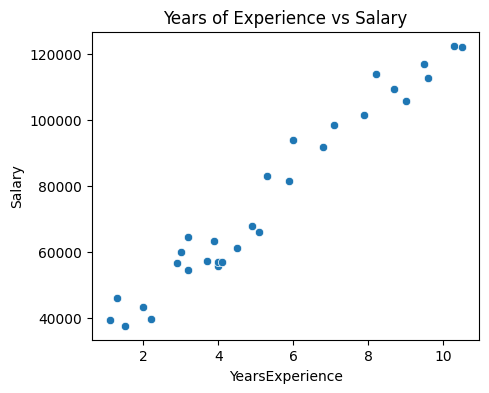

In [4]:
plt.figure(figsize=(5,4))
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title('Years of Experience vs Salary')
plt.show()

In [5]:
X = df.drop('Salary', axis='columns')
y = df['Salary']

In [6]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [7]:
model.fit(X,y)

LinearRegression()

In [8]:
model.predict(np.array([[4]]))

C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([63592.04948449])

In [18]:
model.score(X,y)

0.9565253043191874

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [10]:
model.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred= model.predict(X_test)
y_pred

array([102819.22236331,  37123.21216082,  63956.79379283,  56554.42644607,
        74135.04889462, 107445.70195504])

In [23]:
model.score(X_test,y_test)

0.9446458943278724

In [16]:
from sklearn.metrics import r2_score, mean_squared_error
print("R2:", r2_score(y_test, y_pred))

mse = mean_squared_error(y_test, y_pred)
rsme = np.sqrt(mse)
print("RMSE:", rsme)

R2: 0.9446458943278724
RMSE: 6664.569724364223


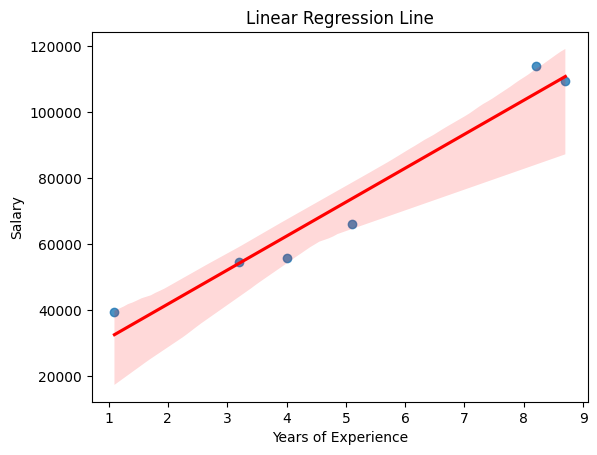

In [ ]:
sns.regplot(x=X_test.squeeze(), y=y_test, line_kws={"color": "red"}) # regplot means regression plot-> it draws a scatter plot and fits and draws a regression line
# .squeeze() as X_test is in 2D and sns expects 1D
#  line_kws means line keyword arguments-> make the regression line red
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression Line")
plt.show()


In [26]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)


Slope: [9252.95918345]
Intercept: 26944.957059029017


In [27]:
print("Train R2:", model.score(X_train, y_train))
print("Test R2:", model.score(X_test, y_test))


Train R2: 0.9597479460527047
Test R2: 0.9446458943278724
